In [3]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile
import os

zip_path = '/content/drive/MyDrive/Intel Classification/archive.zip'
extract_path = '/content/intel-data'

print("Extracting dataset... (tunggu bentar)")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("Selesai!")

for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    if level < 3:
        indent = ' ' * 2 * level
        print(f'{indent}{os.path.basename(root)}/')

Mounted at /content/drive
Extracting dataset... (tunggu bentar)
Selesai!
intel-data/
  seg_train/
    seg_train/
  seg_test/
    seg_test/
  seg_pred/
    seg_pred/


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import shutil
import random

print("tensorflow version:", tf.__version__)
print("semua library berhasil di-import!")

tensorflow version: 2.20.0
semua library berhasil di-import!


In [5]:
# cek path dan jumlah gambar per kelas
train_dir = '/content/intel-data/seg_train/seg_train'
test_dir = '/content/intel-data/seg_test/seg_test'

print("kelas yang tersedia:")
classes = sorted(os.listdir(train_dir))
print(classes)

print("\njumlah gambar per kelas (train):")
total_train = 0
for cls in classes:
    count = len(os.listdir(os.path.join(train_dir, cls)))
    total_train += count
    print(f"  {cls}: {count}")

print(f"\ntotal gambar train: {total_train}")

print("\njumlah gambar per kelas (test):")
total_test = 0
for cls in classes:
    count = len(os.listdir(os.path.join(test_dir, cls)))
    total_test += count
    print(f"  {cls}: {count}")

print(f"\ntotal gambar test: {total_test}")

kelas yang tersedia:
['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

jumlah gambar per kelas (train):
  buildings: 2191
  forest: 2271
  glacier: 2404
  mountain: 2512
  sea: 2274
  street: 2382

total gambar train: 14034

jumlah gambar per kelas (test):
  buildings: 437
  forest: 474
  glacier: 553
  mountain: 525
  sea: 510
  street: 501

total gambar test: 3000


In [6]:
# setup image data generator
img_size = (150, 150)
batch_size = 32

# augmentasi hanya untuk data training, validation split 10% dari train
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.1,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# test tidak di-augmentasi, hanya rescale
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    seed=42
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    seed=42
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

print("\nkelas:", train_generator.class_indices)

Found 12632 images belonging to 6 classes.
Found 1402 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.

kelas: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


In [7]:
# membangun model cnn sequential
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(6, activation='softmax')
])

# compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     6,423,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,814,534 (26.00 MB)

 Trainable params: 6,814,534 (26.00 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# setup callback
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        '/content/best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

# training model
history = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=callbacks
)

Epoch 1/30
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.4412 - loss: 1.3574
Epoch 1: val_accuracy improved from None to 0.53923, saving model to /content/best_model.keras

Epoch 1: finished saving model to /content/best_model.keras
395/395 ━━━━━━━━━━━━━━━━━━━━ 116s 270ms/step - accuracy: 0.5256 - loss: 1.1718 - val_accuracy: 0.5392 - val_loss: 1.0460 - learning_rate: 0.0010
Epoch 2/30
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.6420 - loss: 0.9268
Epoch 2: val_accuracy improved from 0.53923 to 0.69258, saving model to /content/best_model.keras

Epoch 2: finished saving model to /content/best_model.keras
395/395 ━━━━━━━━━━━━━━━━━━━━ 99s 250ms/step - accuracy: 0.6552 - loss: 0.8962 - val_accuracy: 0.6926 - val_loss: 0.8204 - learning_rate: 0.0010
Epoch 3/30
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.7031 - loss: 0.7923
Epoch 3: val_accuracy improved from 0.69258 to 0.74465, saving model to /content/best_model.keras

Epoch 3: finished saving model to

evaluasi di test set:
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.8800 - loss: 0.3406

test accuracy: 0.8800
test loss: 0.3406


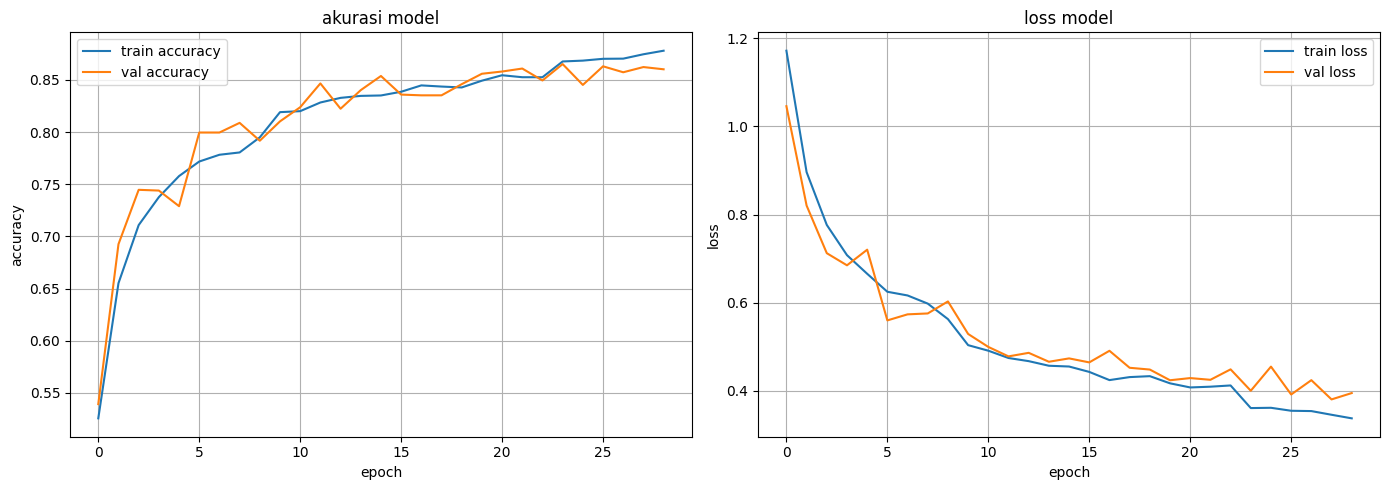

plot berhasil disimpan!


In [9]:
# evaluasi model di test set
print("evaluasi di test set:")
test_loss, test_acc = model.evaluate(test_generator)
print(f"\ntest accuracy: {test_acc:.4f}")
print(f"test loss: {test_loss:.4f}")

# plot akurasi dan loss
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# plot akurasi
axes[0].plot(history.history['accuracy'], label='train accuracy')
axes[0].plot(history.history['val_accuracy'], label='val accuracy')
axes[0].set_title('akurasi model')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('accuracy')
axes[0].legend()
axes[0].grid(True)

# plot loss
axes[1].plot(history.history['loss'], label='train loss')
axes[1].plot(history.history['val_loss'], label='val loss')
axes[1].set_title('loss model')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('/content/plot_hasil.png', dpi=150)
plt.show()
print("plot berhasil disimpan!")

In [14]:
# simpan ke semua format
import shutil

# 1. savedmodel
shutil.rmtree('/content/saved_model', ignore_errors=True)
os.makedirs('/content/saved_model', exist_ok=True)
model.export('/content/saved_model')
print("savedmodel berhasil disimpan!")

# 2. tflite
shutil.rmtree('/content/tflite', ignore_errors=True)
os.makedirs('/content/tflite', exist_ok=True)
converter = tf.lite.TFLiteConverter.from_saved_model('/content/saved_model')
tflite_model = converter.convert()
with open('/content/tflite/model.tflite', 'wb') as f:
    f.write(tflite_model)
with open('/content/tflite/label.txt', 'w') as f:
    f.write('\n'.join(['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']))
print("tflite berhasil disimpan!")

# 3. tfjs
shutil.rmtree('/content/tfjs_model', ignore_errors=True)
os.makedirs('/content/tfjs_model', exist_ok=True)
!tensorflowjs_converter \
    --input_format=tf_saved_model \
    --output_format=tfjs_graph_model \
    /content/saved_model \
    /content/tfjs_model
print("tfjs berhasil disimpan!")

# cek semua file
print("\ncek savedmodel:", os.listdir('/content/saved_model'))
print("cek tflite:", os.listdir('/content/tflite'))
print("cek tfjs:", os.listdir('/content/tfjs_model'))

Saved artifact at '/content/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  140569360459024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140569360460752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140569360462288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140569360460368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140569360462480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140569360461712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140569360463248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140569360462672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140569360463440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140569360464208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1405693604

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


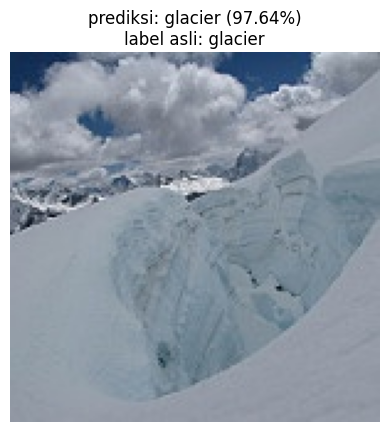

prediksi: glacier
label asli: glacier
confidence: 97.64%


In [15]:
# inference menggunakan tflite
import numpy as np
from tensorflow.keras.preprocessing import image

# ambil satu gambar dari test set untuk dicoba
test_classes = os.listdir(test_dir)
sample_class = test_classes[0]
sample_img_path = os.path.join(test_dir, sample_class, os.listdir(os.path.join(test_dir, sample_class))[0])

# load dan preprocess gambar
img = image.load_img(sample_img_path, target_size=(150, 150))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0).astype(np.float32)

# load tflite model
interpreter = tf.lite.Interpreter(model_path='/content/tflite/model.tflite')
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

interpreter.set_tensor(input_details[0]['index'], img_array)
interpreter.invoke()

output = interpreter.get_tensor(output_details[0]['index'])
predicted_class = classes[np.argmax(output)]
confidence = np.max(output) * 100

# tampilkan gambar dan hasil prediksi
plt.imshow(img)
plt.title(f'prediksi: {predicted_class} ({confidence:.2f}%)\nlabel asli: {sample_class}')
plt.axis('off')
plt.show()

print(f"prediksi: {predicted_class}")
print(f"label asli: {sample_class}")
print(f"confidence: {confidence:.2f}%")

In [17]:
# requirements.txt
reqs = """tensorflow==2.20.0
numpy
matplotlib
scikit-learn
tensorflowjs
Pillow"""

with open('/content/requirements.txt', 'w') as f:
    f.write(reqs)

print("requirements.txt berhasil dibuat!")
print("\nisinya:")
print(reqs)

requirements.txt berhasil dibuat!

isinya:
tensorflow==2.20.0
numpy
matplotlib
scikit-learn
tensorflowjs
Pillow


In [21]:
from google.colab import files
files.download('/content/submission.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>